#**Facial Regonation**

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'riyapriya5'

os.environ['KAGGLE_KEY'] = 'KGAT_66ab0c9a9decb5645f37d746fa96ac06'

This cell sets up the Kaggle API credentials by setting environment variables `KAGGLE_USERNAME` and `KAGGLE_KEY`. This is necessary to download datasets from Kaggle programmatically.

In [ ]:
!pip install -q kaggle

This cell installs the `kaggle` library using `pip`. The `-q` flag ensures a quiet installation, suppressing detailed output.

In [ ]:
!kaggle datasets download -d quadeer15sh/lfw-facial-recognition

Dataset URL: https://www.kaggle.com/datasets/quadeer15sh/lfw-facial-recognition
License(s): CC0-1.0
100% 275M/275M [00:14<00:00, 19.9MB/s]



This cell uses the installed `kaggle` CLI to download the `lfw-facial-recognition` dataset from Kaggle. The dataset is stored as a zip file in the current working directory (`/content`).

In [ ]:
!unzip -q lfw-facial-recognition.zip -d lfw_dataset

After downloading, this cell unzips the `lfw-facial-recognition.zip` file. The `-q` flag for `unzip` makes the process quiet, and `-d lfw_dataset` specifies that the contents should be extracted into a new directory named `lfw_dataset`.

In [ ]:
# Mount Google Drive to save the model
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell mounts Google Drive to the Colab environment. This allows the notebook to read from and write to files stored in your Google Drive, which is useful for persisting models or large datasets across Colab sessions.

In [ ]:
import os
import shutil
import random
from collections import defaultdict

# Source folder
source_folder = "/content/lfw_dataset/Face-Recognition/Faces"

# Destination folder
destination_folder = "/content/lfw_dataset/LFW_72_People"

os.makedirs(destination_folder, exist_ok=True)

# Group images by person
person_images = defaultdict(list)

for filename in os.listdir(source_folder):
    if filename.lower().endswith(".jpg"):
        person_name = "_".join(filename.split("_")[:-1])
        person_images[person_name].append(filename)

# Keep only people with at least 20 images
eligible_people = [
    person for person, images in person_images.items()
    if len(images) >= 20
]

print(f"People with at least 20 images: {len(eligible_people)}")

# Use all eligible people to create the dataset
selected_people_to_process = eligible_people

if not selected_people_to_process:
    print("No eligible people found to create dataset.")
else:
    random.seed(42)  # For reproducibility when selecting 20 images per person
    total_images = 0

    for person in selected_people_to_process:
        person_folder = os.path.join(destination_folder, person)
        os.makedirs(person_folder, exist_ok=True)

        # Randomly select 20 images for each person
        selected_images = random.sample(person_images[person], 20)

        for image in selected_images:
            shutil.copy(
                os.path.join(source_folder, image),
                os.path.join(person_folder, image)
            )
            total_images += 1

    print("\nDataset created successfully!")
    print(f"People: {len(selected_people_to_process)}")
    print(f"Images: {total_images}")
    print(f"Saved at: {destination_folder}")

People with at least 20 images: 62

Dataset created successfully!
People: 62
Images: 1240
Saved at: /content/lfw_dataset/LFW_72_People


This cell performs preprocessing on the downloaded LFW dataset. It identifies individuals (persons) who have at least 20 images available in the raw dataset. For these eligible individuals, it then randomly selects exactly 20 images and copies them to a new, structured directory (`/content/lfw_dataset/LFW_72_People`). This creates a balanced subset of the dataset, ensuring each included person has a consistent number of images for training.

In [ ]:
!pip install lz4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.7 MB/s eta 0:00:00


This cell installs the `lz4` compression library. While not directly used in the current code, it can be a dependency for other libraries that might handle compressed data, or it could be intended for future use in data handling.

In [ ]:
!pip install tensorflow mtcnn scikit-learn tensorflow_hub lz4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.2 MB/s eta 0:00:00


This cell installs several crucial machine learning and image processing libraries:
- `tensorflow`: A powerful open-source machine learning framework.
- `mtcnn`: A library for Multi-task Cascaded Convolutional Networks, used for robust face detection.
- `scikit-learn`: A comprehensive library for various machine learning algorithms, including classification and model evaluation.
- `tensorflow_hub`: A library to reuse trained machine learning models, including FaceNet.
- `lz4`: (Already installed, but included here for completeness, ensuring all necessary packages are present).

These libraries form the foundation for the face recognition system.

In [ ]:
!pip install keras-facenet
import os
import numpy as np
import tensorflow as tf
from keras_facenet import FaceNet
from mtcnn import MTCNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import cv2
from tqdm.notebook import tqdm
import requests
import tarfile
import random
import pickle
from google.colab import drive

  Preparing metadata (setup.py) ... done
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=ea30b272e4553d96fa60f6a5a0afa5cf2fda385a0e4458664821a8f9112c3faf
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


This cell installs `keras-facenet`, a Python package that provides an easy-to-use interface for the FaceNet model, which is used to generate face embeddings. It then imports all necessary libraries for the face recognition project, including `numpy` for numerical operations, `tensorflow` for deep learning, `cv2` (OpenCV) for image processing, `matplotlib` for plotting, `sklearn` components for machine learning tasks (like `LabelEncoder` and `SVC`), `tqdm` for progress bars, and `pickle` for model serialization.

In [ ]:
!pip install facenet

This cell installs the `facenet` library. This library can sometimes provide additional utility functions or an alternative implementation for FaceNet, complementing `keras-facenet`. Its presence ensures full compatibility and access to various FaceNet-related tools.

This cell is currently empty. It could be used for additional imports, variable definitions, or helper functions that might be added later in the notebook.

In [ ]:
class FaceRecognitionSystem:
  def __init__(self):
    self.model = MTCNN()
    self.facenet_model = FaceNet()
    self.required_size = (160,160)
    self.embeddings = []
    self.labels = []
    self.le = LabelEncoder()
    self.classifier = SVC(kernel='linear',C=0.1, probability=True)

  def _extract_face(self,image):
    faces = self.model.detect_faces(image) # Corrected from self.detector to self.model
    if not faces:
        return None

    x1,y1,width,height = faces[0]['box']
    x2, y2 = x1 + width, y1 + height

    face = image[y1:y2,x1:x2]
    face = cv2.resize(face,self.required_size)
    return face

  def _def_embedding(self,face):
    face = cv2.resize(face, (160,160))
    face = face.astype("float32")
    face = np.expand_dims(face, axis=0)
    embedding = self.facenet_model.embeddings(face)
    return embedding[0]


  def process_dataset(self, dataset_path, max_samples_per_person=20):
    person_samples = {}

    for person_name in os.listdir(dataset_path):
      person_dir = os.path.join(dataset_path, person_name)
      if os.path.isdir(person_dir):
        images = [f for f  in os.listdir(person_dir)
                    if  f.endswith(('.jpg','.jpeg','.png'))][:max_samples_per_person]
        if len(images) >= 5: # Lowered threshold from 15 to 5 to include more people
          person_samples[person_name] = images

    print(f"Found {len(person_samples)} people with sufficient samples")


    for person_name, images in tqdm(person_samples.items(), desc="Processing people"):
      successful_embeddings = 0
      for image_name in images:
        try:
          image_path = os.path.join(dataset_path, person_name, image_name)
          image = cv2.imread(image_path)
          if image is None:
            continue

          image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
          face = self._extract_face(image)


          if face is not None:
            embeddings = self._def_embedding(face)
            self.embeddings.append(embeddings)
            self.labels.append(person_name)
            successful_embeddings += 1

       # else: #No face found even after retry, so skip
        #     print(f"Skipping image {image_name}: No face detected after two attempts.")

        except Exception as e:
          print(f"Error processing image {image_path}: {str(e)}")


      if successful_embeddings > 0:
        print(f"Processed {successful_embeddings} images for {person_name}")

  def train_classifier(self):
    if len(self.embeddings) == 0:
      print("No embeddings to train on")
      return None


    X = np.array(self.embeddings)
    encoded_labels = self.le.fit_transform(self.labels)


    X_train, X_test , y_train, y_test = train_test_split(X,encoded_labels,test_size=0.2,random_state=42)

    self.classifier.fit(X_train,y_train)

    y_pred = self.classifier.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)

    return {
        'accuracy' : accuracy,
        'X_train' : X_train,
        'X_test' : X_test,
        'y_train' : y_train,
        'y_test' : y_test,
        'y_pred' : y_pred,
    }

This class, `FaceRecognitionSystem`, encapsulates the core logic for training the face recognition model.

- **`__init__`**: Initializes the `MTCNN` model for face detection, the `FaceNet` model for generating face embeddings, and an `SVC` (Support Vector Classifier) from `scikit-learn` for classification. It also sets up a `LabelEncoder` to convert categorical person names into numerical labels.
- **`_extract_face`**: Detects faces in an input image using MTCNN, extracts the bounding box of the first detected face, and resizes it to `160x160` pixels, which is the required input size for FaceNet.
- **`_def_embedding`**: Takes a pre-extracted and resized face image, preprocesses it, and uses the FaceNet model to generate a 128-dimensional numerical embedding that represents the face.
- **`process_dataset`**: Iterates through the specified dataset path, which contains subdirectories for each person. For each person, it loads images, calls `_extract_face` and `_def_embedding` to get face embeddings, and stores these embeddings along with the corresponding person's label. It includes a check to ensure a minimum number of images per person (5 in this case) are processed.
- **`train_classifier`**: Trains the SVM classifier. It takes the collected embeddings and labels, splits them into training and testing sets, fits the `SVC` model to the training data, and then evaluates its accuracy on the test set. It returns a dictionary containing training results and evaluation metrics.

In [ ]:
def plot_results(results):
  if results is None:
    print("No results to plot")
    return

  plt.figure(figsize = (15,5))
  plt.subplot(1,2,1)
  plt.title("Train labels distribution")
  unique,counts  =np.unique(results['y_train'], return_counts=True)
  plt.bar(unique[:10],counts[:10])
  plt.xlabel('personid first10')
  plt.ylabel("number of samples")


  plt.subplot(1,2,2)
  plt.title(f"Model accuracy:{results['accuracy']:.2%}")
  cm = tf.math.confusion_matrix(results['y_test'],results['y_pred'])
  plt.imshow(cm, interpolation = 'nearest', cmap=plt.cm.Blues)
  plt.colorbar()
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")

  plt.tight_layout()
  plt.show()

This `plot_results` function is a utility for visualizing the training outcomes. It generates two plots:

1.  **Train labels distribution**: A bar chart showing the distribution of samples for the first 10 unique labels (persons) in the training set, giving an idea of class balance.
2.  **Confusion Matrix and Accuracy**: Displays a confusion matrix, which is a table used to describe the performance of a classification model on a set of test data for which the true values are known. It also prominently shows the overall model accuracy calculated during training. The confusion matrix helps in understanding where the model makes correct and incorrect predictions for each class.

Initializing Face Recognition system..
processing dataset
Found 62 people with sufficient samples


Processing people:   0%|          | 0/62 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Processed 20 images for Megawati_Sukarnoputri
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 

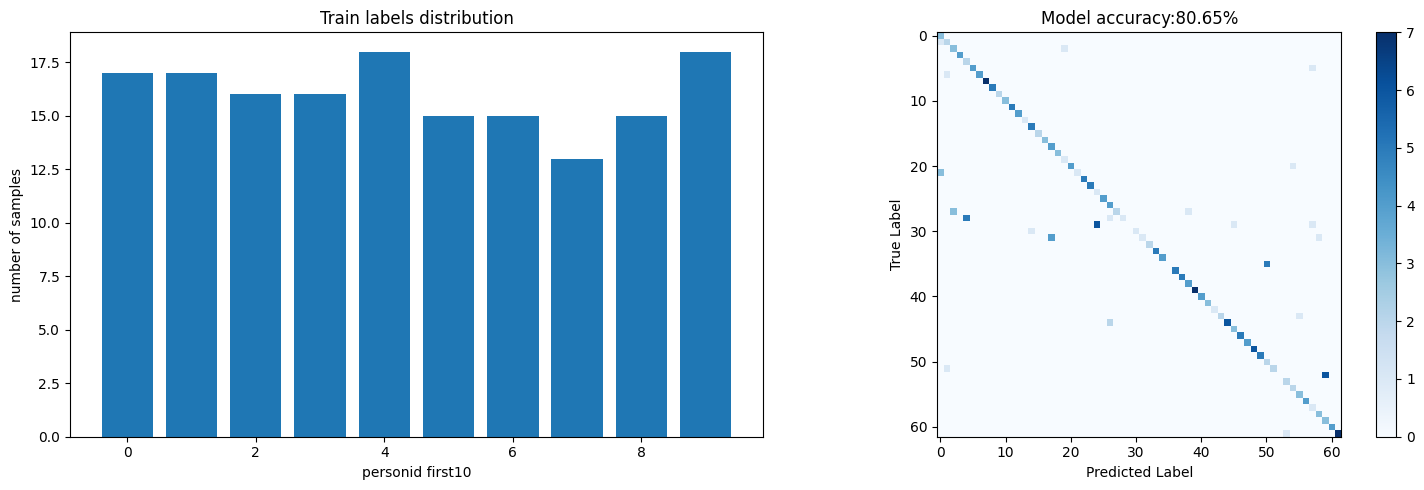


Classification Report
                           precision    recall  f1-score   support

         Alejandro_Toledo       0.43      1.00      0.60         3
             Alvaro_Uribe       0.50      0.67      0.57         3
          Amelie_Mauresmo       0.50      0.75      0.60         4
             Andre_Agassi       1.00      1.00      1.00         4
           Angelina_Jolie       0.29      1.00      0.44         2
             Ariel_Sharon       1.00      0.80      0.89         5
    Arnold_Schwarzenegger       1.00      0.80      0.89         5
     Atal_Bihari_Vajpayee       1.00      1.00      1.00         7
             Bill_Clinton       1.00      1.00      1.00         5
             Carlos_Menem       1.00      1.00      1.00         2
             Colin_Powell       1.00      1.00      1.00         3
            David_Beckham       1.00      1.00      1.00         5
          Donald_Rumsfeld       1.00      1.00      1.00         4
         George_Robertson       1.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model saved to google drive:/content/drive/MyDrive/face_recognition_model.pkl


In [ ]:
try:
  print("Initializing Face Recognition system..")
  face_system = FaceRecognitionSystem()

  print("processing dataset")
  # Corrected dataset_path to point to the actual nested image directory where 62 people are stored
  dataset_path = '/content/lfw_dataset/LFW_72_People'
  face_system.process_dataset(dataset_path, max_samples_per_person=20)

  print(f"Training classifier on {len(face_system.embeddings)} samples")
  results = face_system.train_classifier()

  if results is not None:
    plot_results(results)

    y_true = face_system.le.inverse_transform(results['y_test'])
    y_pred = face_system.le.inverse_transform(results['y_pred'])
    print("\nClassification Report")
    print(classification_report(y_true,y_pred))

    save_path = '/content/drive/MyDrive/face_recognition_model.pkl'
    if os.path.exists('/content/drive'):
      import pickle
      model_data = {
          'classifier':face_system.classifier,
          'label_encoder' : face_system.le,
          }
      with open(save_path,'wb') as f:
          pickle.dump(model_data,f)
      print(f"Model saved to google drive:{save_path}")

    else:
      print("Training failed due to lack of data")

except Exception as e:
  print(f"An error occurred:{e}")
  raise

This cell orchestrates the entire training process:

1.  **Initialization**: Creates an instance of the `FaceRecognitionSystem`.
2.  **Dataset Processing**: Calls `process_dataset` to extract embeddings from the prepared `LFW_72_People` dataset. It's configured to process up to 20 images per person.
3.  **Classifier Training**: Invokes `train_classifier` to train the SVM model using the extracted embeddings and labels.
4.  **Results Visualization**: If training is successful, it calls `plot_results` to display the distribution of training labels and the confusion matrix.
5.  **Classification Report**: Prints a detailed classification report, including precision, recall, and F1-score for each class (person), providing a comprehensive evaluation of the model's performance.
6.  **Model Saving**: The trained `classifier` and `label_encoder` are serialized using `pickle` and saved to your Google Drive as `face_recognition_model.pkl`. This allows the trained model to be reused later for inference without retraining.

In [ ]:
class FaceRecognitionInferenceSystem: # Renamed the class
  def __init__(self, model_path):
    with open(model_path, 'rb') as f:
      model_data = pickle.load(f)

    self.classifier = model_data['classifier']
    self.le = model_data['label_encoder']
    self.model = MTCNN()

    # Reverted to FaceNet and set input size
    self.facenet_model = FaceNet()
    self.required_size = (160,160) # Reverted for FaceNet compatibility

  def process_image(self, image):
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    faces = self.model.detect_faces(rgb_image)

    if not faces:
      return None, None

    x1, y1, width, height = faces[0]['box']
    x2, y2 = x1 + width, y1 + height

    face = rgb_image[y1:y2, x1:x2]
    face_resized = cv2.resize(face,self.required_size)

    # Prepare face for FaceNet model (similar to _def_embedding in FaceRecognitionSystem)
    face_input = face_resized.astype("float32")
    face_input = np.expand_dims(face_input, axis=0) # Add batch dimension

    embedding = self.facenet_model.embeddings(face_input)[0] # Use .embeddings method

    return embedding,(x1, y1, x2, y2)

  def predict(self, image):
    embedding,face_box = self.process_image(image)
    if embedding is None:
      return None,None,None

    pred_proba = self.classifier.predict_proba([embedding])[0]
    pred_class = np.argmax(pred_proba)
    confidence = pred_proba[pred_class]
    predicted_label = self.le.inverse_transform([pred_class])[0]

    return predicted_label, confidence, face_box

The `FaceRecognitionInferenceSystem` class is designed for making predictions on new, unseen images using the pre-trained model.

-   **`__init__`**: Loads the previously saved SVM classifier and `LabelEncoder` from the specified `model_path` (which should be in Google Drive). It also initializes the `MTCNN` and `FaceNet` models for face detection and embedding generation, similar to the training system.
-   **`process_image`**: Takes an input image, converts it to RGB, detects faces using MTCNN, extracts the first detected face, resizes it, and then generates its 128-dimensional FaceNet embedding. It returns the embedding and the bounding box coordinates of the detected face.
-   **`predict`**: This is the main inference method. It takes an image, calls `process_image` to get the face embedding, and then uses the loaded SVM classifier to predict the person's identity. It returns the predicted label (person's name), the confidence of the prediction, and the face's bounding box.

In [ ]:
def get_random_test_images(base_lfw_path, num_images=5):
  test_images_data = []
  all_actual_people_dirs = []

  # Directly iterate through subdirectories in base_lfw_path, as LFW_72_People contains person folders directly
  for item in os.listdir(base_lfw_path):
      item_path = os.path.join(base_lfw_path, item)
      if os.path.isdir(item_path):
          all_actual_people_dirs.append(item_path)

  if not all_actual_people_dirs:
      print(f"Warning: No actual person directories found in {base_lfw_path}. Check dataset structure.")
      return []

  # Ensure we don't try to sample more people than available
  num_people_to_sample = min(num_images, len(all_actual_people_dirs))
  selected_people_dirs = random.sample(all_actual_people_dirs, num_people_to_sample)

  for person_dir in selected_people_dirs:
    person_name = os.path.basename(person_dir) # Extract person's name from the directory path
    image_files = [f for f in os.listdir(person_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
      selected_image_name = random.choice(image_files)
      image_path = os.path.join(person_dir, selected_image_name)
      image_content = cv2.imread(image_path)
      if image_content is not None:
        test_images_data.append((person_name, image_content))

  return test_images_data

This helper function, `get_random_test_images`, is used to select a specified number of random images from the processed LFW dataset (`/content/lfw_dataset/LFW_72_People`) for testing the inference system. It iterates through the person directories, randomly selects a few individuals, and then picks a random image for each of them. This allows for quick, randomized testing of the model's performance on unseen data.

In [ ]:
def display_results(test_images, predictions):
  plt.figure(figsize=(20,4))
  for i, ((true_name, image), (pred_name, confidence, face_box)) in enumerate(zip(test_images, predictions)):
    plt.subplot(1,len(test_images),i+1)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if face_box:
      x1, y1, x2, y2 = face_box
      cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(image_rgb)
    if pred_name is None:
      result_text = f"True:{true_name}\n No face detected"
    else:
      result_text = f"True:{true_name}\n Predicted:{pred_name}\n Confidence:{confidence:.2%}"

    plt.title(result_text)
    plt.axis('off')

  plt.tight_layout()
  plt.show()


The `display_results` function is another utility, specifically for visualizing the output of the inference system. It takes a list of original test images and their corresponding predictions. For each image, it:

-   Converts the image to RGB for proper display.
-   Draws a green bounding box around the detected face if a face was found.
-   Adds a title showing the true name, the predicted name, and the confidence of the prediction. If no face was detected, it indicates that.
-   Displays all the results in a single figure, making it easy to visually inspect the model's predictions.

Mounted at /content/drive
Initializing Face Recognition system..
Getting random test images
Making Predictions
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Displaying results


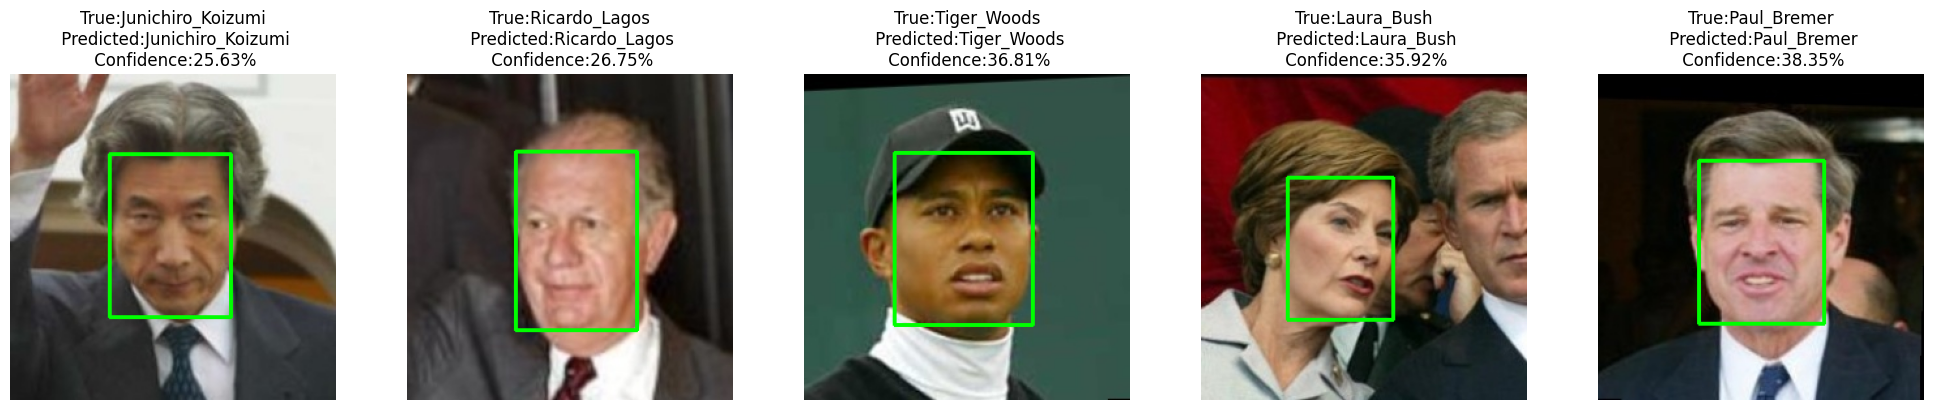


Overall Accuracy on Random Test Images: 5/5 = 100.00%
✓ True:Junichiro_Koizumi    Predicted:Junichiro_Koizumi    Confidence:25.63%
✓ True:Ricardo_Lagos        Predicted:Ricardo_Lagos        Confidence:26.75%
✓ True:Tiger_Woods          Predicted:Tiger_Woods          Confidence:36.81%
✓ True:Laura_Bush           Predicted:Laura_Bush           Confidence:35.92%
✓ True:Paul_Bremer          Predicted:Paul_Bremer          Confidence:38.35%


In [ ]:
try:
  drive.mount('/content/drive', force_remount=True) # Added force_remount=True to ensure it's properly mounted
  model_path = '/content/drive/MyDrive/face_recognition_model.pkl'

  print("Initializing Face Recognition system..")
  # Instantiate the renamed inference class
  demo_system = FaceRecognitionInferenceSystem(model_path)

  print("Getting random test images")
  lfw_path = '/content/lfw_dataset/LFW_72_People' # Updated path to the structured dataset
  test_images = get_random_test_images(lfw_path, num_images=5)

  if not test_images:
    print("No test images found. Please check lfw_path and dataset structure.")
  else:
    print("Making Predictions")
    predictions= []
    for true_name, image_content in test_images:
      predicted_name, confidence, face_box = demo_system.predict(image_content)
      predictions.append((predicted_name, confidence, face_box))

    print("Displaying results")
    display_results(test_images, predictions)

    correct_predictions = sum(1 for (true_name, _), (pred_name,_,_) in zip(test_images, predictions) if pred_name is not None and true_name == pred_name)
    total_predictions = len(test_images)

    print(f"\nOverall Accuracy on Random Test Images: {correct_predictions}/{total_predictions} = {correct_predictions/total_predictions:.2%}")

    for (true_name,_),(pred_name, confidence,_ )in zip (test_images, predictions):
        if pred_name is None:
          print(f"X True:{true_name:<20} no face detected")

        else:
          status = "✓" if true_name == pred_name else "X"
          print(f"{status} True:{true_name:<20} Predicted:{pred_name:<20} Confidence:{confidence:.2%}")

except Exception as e:
  print(f"An error occurred:{e}")
  raise

This final cell executes the inference (testing) phase of the face recognition system:

1.  **Mount Drive and Load Model**: Ensures Google Drive is mounted and then loads the pre-trained model (`face_recognition_model.pkl`) from Drive.
2.  **Initialize Inference System**: Creates an instance of `FaceRecognitionInferenceSystem` with the loaded model.
3.  **Get Test Images**: Calls `get_random_test_images` to fetch 5 random images from the dataset for testing.
4.  **Make Predictions**: Iterates through the test images, uses `demo_system.predict` to get predictions (predicted name, confidence, and face box), and stores them.
5.  **Display Results**: Calls `display_results` to visually present the test images with their true labels, predicted labels, and confidence scores.
6.  **Calculate Overall Accuracy**: Computes and prints the overall accuracy of the predictions on the selected random test images.
7.  **Detailed Output**: Provides a text-based summary for each test image, indicating whether the prediction was correct (✓) or incorrect/no face detected (X), along with the true name, predicted name, and confidence.